# Cosmological subhalo impacts on GD-1

How many subhalos hit GD-1 under a given dark matter model, and what are they?

Set the model in the next cell and run the notebook. Two knobs matter most:

- `C_SCALE` — infall mass-concentration relation relative to pyHalo CDM. Denser subhalos
  survive tidal stripping better, so more of them are still around: this raises the rate.
- `SLOPE` — subhalo mass function slope, `dN/dM ~ M**SLOPE`. CDM is `-1.9`.

The long version of this notebook, with the survival calibration and its validation, is
`cosmological_subhalos.ipynb`.

In [1]:
# ----------------------------------------------------------------- dark matter model
C_SCALE       = 1.0        # infall MCR / CDM   (1.0 = CDM)
SLOPE         = -1.9       # dN/dM ~ M**SLOPE   (-1.9 = CDM)
NORMALIZATION = 1.0        # overall multiplier on the rate
M_HM          = 0.0        # WDM half-mode mass [Msun]; 0 = CDM

# ----------------------------------------------------------------- what counts as an impact
LOG10M_WINDOW = (5.0, 8.3)  # bound-mass window impacts are drawn from [log10 Msun]
V_CHAR        = 100.0       # characteristic relative speed for b_max [km/s]
DV_MIN        = 0.05         # faintest velocity kick worth counting [km/s]
B_CEILING     = 8.0         # hard cap on b_max [kpc]

# ----------------------------------------------------------------- numerics
N_POP  = 150_000            # pyHalo population size
SEED   = 1
T_AGE  = 3_000.0             # stream dynamical age [Myr]

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from astropy import units as u
import diffrax

jax.config.update("jax_enable_x64", True)

import streamsculptor as ssc
from streamsculptor import potential
from streamsculptor import JaxCoords as jc
from streamsculptor.main import usys
from streamsculptor.cosmological import (
    DarkMatterModel, SubhaloPopulation, KickCrossSection, ImpactRates,
)

PALETTE = ["#0072B2", "#E69F00", "#009E73", "#D55E00"]
INK, MUTED = "#1a1a1a", "#8a8a8a"

## 1. GD-1

The progenitor orbit sets where the stream sits in the subhalo distribution

In [3]:
@jax.jit
def get_phi1(stream):
    # ICRS -> GD-1 phi1 [deg], rotation matrix from Koposov+2010
    R = jnp.array([[-0.4776303088, -0.1738432154, 0.8611897727],
                   [0.510844589, -0.8524449229, 0.111245042],
                   [0.7147776536, 0.4930681392, 0.4959603976]])
    ra, dec, _ = jax.vmap(jc.simcart_to_icrs)(stream[:, :3])
    ra, dec = ra * jnp.pi / 180, dec * jnp.pi / 180
    icrs = jnp.vstack([jnp.cos(ra) * jnp.cos(dec),
                       jnp.sin(ra) * jnp.cos(dec), jnp.sin(dec)]).T
    v = jnp.einsum("ij,kj->ki", R, icrs)
    return jnp.arctan2(v[:, 1], v[:, 0]) * 180 / jnp.pi

prog = jnp.load("../data/GD1_prog/GD1_progenitor.npy", allow_pickle=True).item()
prog_wtoday = jnp.hstack([prog.pos.xyz.to(u.kpc).value,
                          prog.vel.d_xyz.to(u.kpc / u.Myr).value])

pot = potential.GalaMilkyWayPotential(units=usys)
IC = pot.integrate_orbit(w0=prog_wtoday, t0=0.0, t1=-T_AGE,
                         ts=jnp.array([-T_AGE])).ys[0]

ts = jnp.hstack([jnp.linspace(-T_AGE, -300.0, 2_000), jnp.array([0.0])])
lead, trail = pot.gen_stream_scan(prog_w0=IC, ts=ts, seed_num=532, Msat=1e4,
                                  atol=1e-6, rtol=1e-6, solver=diffrax.Dopri5())
stream = jnp.vstack([lead, trail])

l_obs = ssc.compute_stream_length(stream=stream, phi1=get_phi1(stream))
prog_orb = pot.integrate_orbit(w0=IC, t0=-T_AGE, t1=0.0,
                               ts=jnp.linspace(-T_AGE, 0.0, 500))
r_orb = np.linalg.norm(np.asarray(prog_orb.ys[:, :3]), axis=1)

print(f"stream length today  {float(l_obs):.1f} kpc")


stream length today  24.6 kpc


## 2. The model, and the rate

`amplitude` is the survival enhancement relative to CDM: the factor by which the subhalo
number density changes when the infall MCR is scaled. It multiplies the rate, and is
exactly 1 at `C_SCALE = 1`.

In [4]:
model = DarkMatterModel(c_scale=C_SCALE, slope=SLOPE,
                        normalization=NORMALIZATION, M_hm=M_HM)

population = SubhaloPopulation(model, log10M_bound_range=LOG10M_WINDOW,
                               N=N_POP, seed=SEED)

xsec = KickCrossSection(v_char=V_CHAR, dV_min=DV_MIN, b_ceiling=B_CEILING)

rates = ImpactRates(population, xsec, orbit=prog_orb, t_age=T_AGE, l_obs=l_obs,
                    prog_today=prog_wtoday, first_strip_lead=lead[0],
                    first_strip_trail=trail[0], pot=pot)

rate = rates.expected_impacts()
print(f"model               {model.label}")
print(f"survival amplitude  {rates.amplitude:.3f}")
print(f"expected impacts    {rate:.2f}   "
      f"({LOG10M_WINDOW[0]:g} < log10 M_bound < {LOG10M_WINDOW[1]:g})")
print(f"b_max ceiling above {xsec.m_ceiling:.2e} Msun")

model               c=1, slope=-1.9
survival amplitude  1.000
expected impacts    108.84   (5 < log10 M_bound < 8.3)
b_max ceiling above 4.65e+06 Msun


## 3. Draw a realization

`sample_impactors` Poisson-draws the number of impacts, then resamples the pyHalo
population weighted by $w_i\,b_{\rm max}(M_i)$. The pyhalo raw samples are not a fair draw of the
population, because the encounter cross-section (e.g., max impact param to consider) grows with mass.

In [5]:
key = jax.random.PRNGKey(103)
cat = rates.sample_impactors(key)

# Impact parameters, uniform in [0, b_max] per impactor 
b_impact = np.random.default_rng(0).uniform(0.0, cat["b_max"])

print(cat.summary(), "\n")
print("  ".join(f"{k:>10s}" for k in cat.keys()))
for i in range(min(8, len(cat))):
    print("  ".join(f"{cat[k][i]:10.3g}" for k in cat.keys()))

N=108  median M_bound=1.16e+06  f(>1e7)=0.074  median r_s=0.276 kpc 

   m_bound    m_infall    c_infall    z_infall  t_since_infall     f_bound        rhos          rs          ft          rt       b_max
  3.68e+06    2.01e+07        7.37         2.6        11.3       0.183    4.16e+07       0.314        0.88       0.215        6.32
  5.37e+06    2.25e+07        7.47        2.15        10.7       0.239    2.95e+07       0.365       0.906        0.33           8
  1.71e+06    2.44e+07        9.04        1.94        10.4      0.0703    3.83e+07        0.33       0.775       0.122        2.95
  3.72e+05    7.22e+05        17.1       0.712        6.52       0.515    4.85e+07      0.0847       0.968       0.446        0.64
  3.85e+05    1.63e+06        20.1        0.63        6.06       0.236    6.66e+07      0.0976       0.905       0.235       0.662
  1.43e+06    1.19e+07        12.8        1.33        9.06        0.12    4.84e+07       0.226       0.836       0.184        2.46
   2.8e+0

## 4. Plots

- **(a)** the predicted bound-mass distribution, $dN_{\rm enc}/d\log_{10}M$ — the area under
  it is the expected number of impacts — with this realization's impactors as a histogram
  in the same units.
- **(b)** $b_{\rm max}$ vs bound mass. Linear in $M$ until the ceiling.
- **(c)** the Poisson scatter in the number of impacts around the expected rate.
- **(d)** sampled impact parameter vs bound mass. The envelope is $b_{\rm max}(M)$.

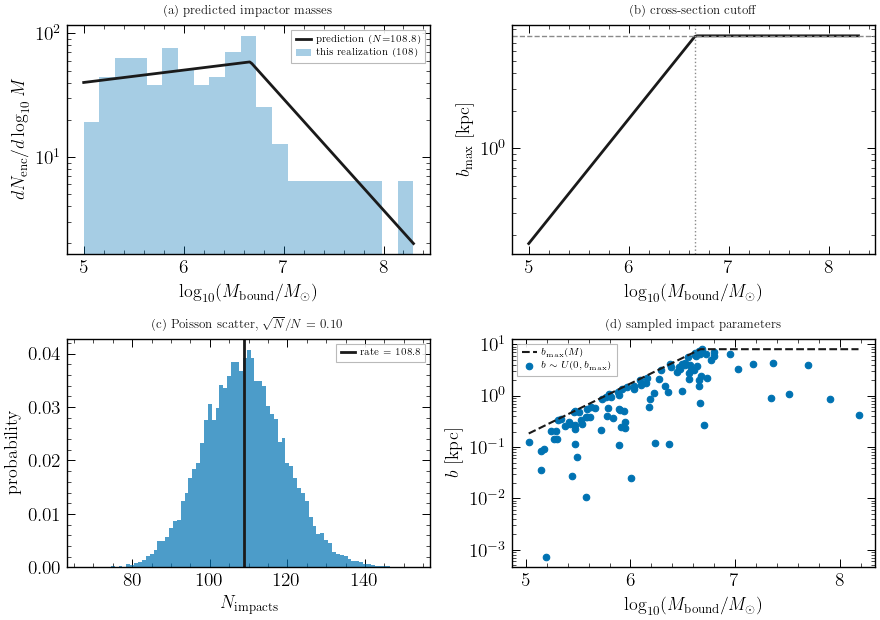

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(9.0, 6.4))
(ax_a, ax_b), (ax_c, ax_d) = axes

# --- (a) predicted bound-mass distribution -------------------------------------
grid = np.linspace(*LOG10M_WINDOW, 150)
dN = np.asarray(rates.dN_dlog10M(jnp.asarray(grid)))

bins = np.linspace(*LOG10M_WINDOW, 22)
dex = np.diff(bins)[0]
counts, _ = np.histogram(np.log10(cat["m_bound"]), bins=bins)
ax_a.bar(0.5 * (bins[:-1] + bins[1:]), counts / dex, width=dex, color=PALETTE[0],
         alpha=0.35, label=f"this realization ({len(cat)})")
ax_a.plot(grid, dN, lw=2, color=INK, label=f"prediction ($N$={rate:.1f})")
ax_a.set_yscale("log")
ax_a.set_xlabel(r"$\log_{10}(M_{\rm bound}/M_\odot)$")
ax_a.set_ylabel(r"$dN_{\rm enc}/d\log_{10}M$")
ax_a.legend(fontsize=7)
ax_a.set_title("(a) predicted impactor masses", fontsize=9, color=INK)

# --- (b) b_max ------------------------------------------------------------------
ax_b.plot(grid, xsec(jnp.asarray(grid)), lw=2, color=INK)
ax_b.axhline(B_CEILING, ls="--", lw=1, color=MUTED)
ax_b.axvline(np.log10(xsec.m_ceiling), ls=":", lw=1, color=MUTED)
ax_b.set_yscale("log")
ax_b.set_xlabel(r"$\log_{10}(M_{\rm bound}/M_\odot)$")
ax_b.set_ylabel(r"$b_{\rm max}$ [kpc]")
ax_b.set_title(r"(b) cross-section cutoff", fontsize=9, color=INK)

# --- (c) Poisson scatter --------------------------------------------------------
draws = np.asarray(jax.random.poisson(jax.random.PRNGKey(1), rate, shape=(20_000,)))
ax_c.hist(draws, bins=np.arange(draws.min(), draws.max() + 2) - 0.5,
          color=PALETTE[0], alpha=0.7, density=True)
ax_c.axvline(rate, color=INK, lw=2, label=f"rate = {rate:.1f}")
ax_c.set_xlabel(r"$N_{\rm impacts}$")
ax_c.set_ylabel("probability")
ax_c.legend(fontsize=7)
ax_c.set_title(f"(c) Poisson scatter, "
               r"$\sqrt{N}/N$ = " f"{1/np.sqrt(rate):.2f}", fontsize=9, color=INK)

# --- (d) impact parameters ------------------------------------------------------
order = np.argsort(cat["m_bound"])
ax_d.plot(np.log10(cat["m_bound"][order]), cat["b_max"][order], lw=1.5, ls="--",
          color=INK, label=r"$b_{\rm max}(M)$")
ax_d.scatter(np.log10(cat["m_bound"]), b_impact, s=22, color=PALETTE[0],
             label=r"$b \sim U(0, b_{\rm max})$")
ax_d.set_yscale("log")
ax_d.set_xlabel(r"$\log_{10}(M_{\rm bound}/M_\odot)$")
ax_d.set_ylabel(r"$b$ [kpc]")
ax_d.legend(fontsize=7)
ax_d.set_title("(d) sampled impact parameters", fontsize=9, color=INK)


fig.tight_layout()

## 5. The tidally evolved TNFWs

The impactors as profiles: `rhos`, `rs` from the infall NFW, and the Du+2024 tidal track's
truncation `rt` with normalization `ft`. Note `rt` is set in units of the infall virial
radius, so at fixed bound mass it barely responds to `C_SCALE`. The compactness shows up
in `rs`, and hence in `rt/rs`.

  m_bound  median  1.164e+06   range  1.067e+05 -  1.504e+08
     rhos  median  3.943e+07   range   6.39e+06 -  1.536e+08
       rs  median     0.2765   range    0.05404 -      2.559
       rt  median     0.1778   range    0.01542 -      1.357
       ft  median     0.8337   range     0.2796 -     0.9885
  f_bound  median     0.1177   range  0.0004176 -     0.7475
 c_infall  median      11.73   range      3.577 -      29.79


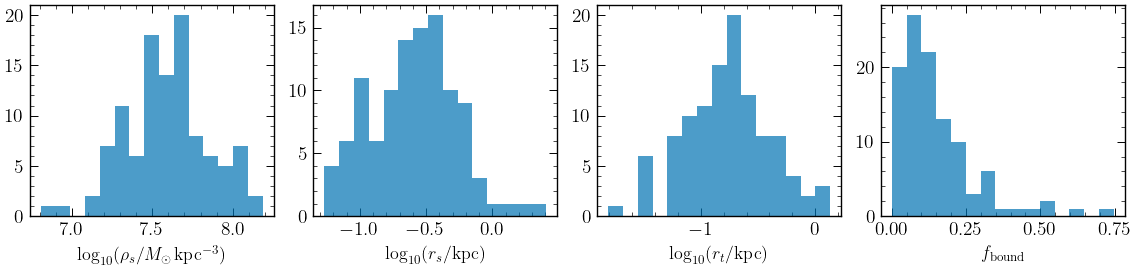

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(11.5, 2.9))

for ax, (vals, lbl) in zip(axes, [
    (np.log10(cat["rhos"]), r"$\log_{10}(\rho_s/M_\odot\,{\rm kpc^{-3}})$"),
    (np.log10(cat["rs"]),   r"$\log_{10}(r_s/{\rm kpc})$"),
    (np.log10(cat["rt"]),   r"$\log_{10}(r_t/{\rm kpc})$"),
    (cat["f_bound"],        r"$f_{\rm bound}$"),
]):
    ax.hist(vals, bins=15, color=PALETTE[0], alpha=0.7)
    ax.set_xlabel(lbl)
  
fig.tight_layout()

for k in ("m_bound", "rhos", "rs", "rt", "ft", "f_bound", "c_infall"):
    v = cat[k]
    print(f"{k:>9s}  median {np.median(v):10.4g}   "
          f"range {np.min(v):10.4g} - {np.max(v):10.4g}")

### Infall times

`cat["t_since_infall"]` is the lookback time at accretion in **Gyr**, alongside
`cat["z_infall"]`. These are the surviving subhalos only: every impactor in the catalog
landed inside the bound-mass window after tidal stripping, so halos that were destroyed or
stripped below the window never appear.


time since infall [Gyr]: median 9.38, 16-84 pct 5.40-11.28, max 12.74
z_infall:                median 1.45, max 5.47

median time since infall [Gyr]:
  all infall halos        12.01
  in the bound window     11.56
  impactors (+ b_max wt)  9.38


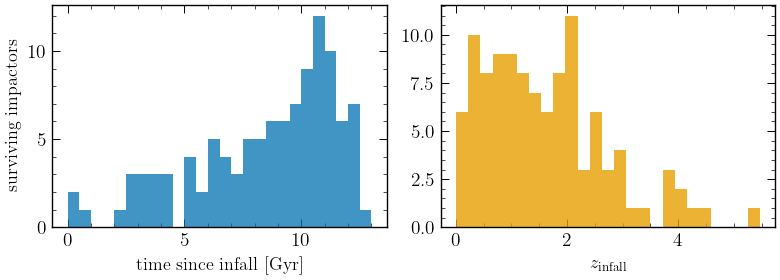

In [10]:
t_inf = cat["t_since_infall"]
z_inf = cat["z_infall"]

fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.0))

axes[0].hist(t_inf, bins=np.linspace(0, 13, 27), color=PALETTE[0], alpha=0.75)
axes[0].set_xlabel("time since infall [Gyr]")
axes[0].set_ylabel("surviving impactors")

axes[1].hist(z_inf, bins=25, color=PALETTE[1], alpha=0.8)
axes[1].set_xlabel(r"$z_{\rm infall}$")


fig.tight_layout()

print(f"time since infall [Gyr]: median {np.median(t_inf):.2f}, "
      f"16-84 pct {np.percentile(t_inf, 16):.2f}-{np.percentile(t_inf, 84):.2f}, "
      f"max {t_inf.max():.2f}")
print(f"z_infall:                median {np.median(z_inf):.2f}, "
      f"max {z_inf.max():.2f}")

# Survivors vs the population they were drawn from, both weighted the same way.
draw = rates.population.draw
print(f"\nmedian time since infall [Gyr]:")
print(f"  all infall halos        {np.median(draw.t_since_infall):.2f}")
print(f"  in the bound window     {np.median(rates.population.t_since_infall):.2f}")
print(f"  impactors (+ b_max wt)  {np.median(t_inf):.2f}")

## 6. Many realizations at once

`impactor_sampler` returns a jittable, vmappable `key -> dict` with fixed-size output, so a
whole ensemble of catalogs comes out of one call. Everything key-independent — the pyHalo
population, the survival amplitude, the sampling CDF — is baked in when the sampler is
built, so each realization is a Poisson draw plus a gather.

Fixed size means padding. Slots past the drawn `n_impacts` get zero mass and **zero
density** but **unit radii**: with `rhos = 0` a padded subhalo contributes exactly nothing
to the potential, while zero radii would put 0/0 into every profile evaluation. `valid` is
the mask.

Size the array with `suggest_max_num_impacts()` (rate + 5sigma)

In [11]:
MAX_NUM_IMPACTS = rates.suggest_max_num_impacts(n_sigma=5.0)
MAX_NUM_IMPACTS

161

In [15]:
MAX_NUM_IMPACTS = rates.suggest_max_num_impacts(n_sigma=5.0)
N_REALIZATIONS  = 100

sampler = rates.impactor_sampler(max_num_impacts=MAX_NUM_IMPACTS)
batch = jax.vmap(sampler)(jax.random.split(jax.random.PRNGKey(1), N_REALIZATIONS))

n_imp = np.asarray(batch["n_impacts"])
valid = np.asarray(batch["valid"])

print(f"max_num_impacts   {MAX_NUM_IMPACTS}   (rate {rate:.1f} + 5 sqrt(rate))")
print(f"array shape       {batch['m_bound'].shape}")
print(f"n_impacts         mean {n_imp.mean():.2f}, max {n_imp.max()}")
print(f"overflowed        {(n_imp > MAX_NUM_IMPACTS).sum()} / {N_REALIZATIONS} realizations")
print(f"rhos == 0 in every padded slot -> "
      f"{bool((np.asarray(batch['rhos'])[~valid] == 0).all())}")

max_num_impacts   161   (rate 108.8 + 5 sqrt(rate))
array shape       (100, 161)
n_impacts         mean 108.59, max 132
overflowed        0 / 100 realizations
rhos == 0 in every padded slot -> True


realization 0: N=125  median M_bound=1.31e+06  f(>1e7)=0.096  median r_s=0.277 kpc
heaviest impactor: median 7.59e+07, 90th pct 1.43e+08 Msun


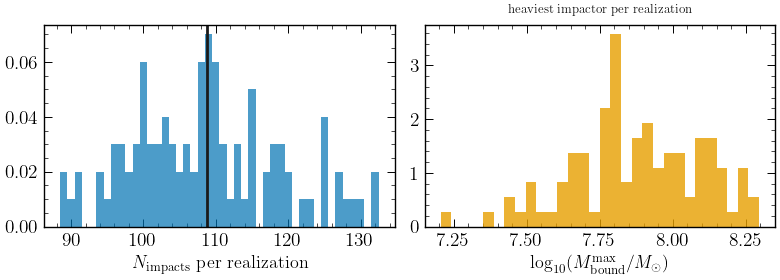

In [13]:
# Ensemble statistics, and one realization pulled back out as a normal catalog.
from streamsculptor.cosmological import ImpactorCatalog

m_all = np.asarray(batch["m_bound"])
heaviest = np.where(valid, m_all, 0.0).max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.0))

axes[0].hist(n_imp, bins=np.arange(n_imp.min(), n_imp.max() + 2) - 0.5,
             color=PALETTE[0], alpha=0.7, density=True)
axes[0].axvline(rate, color=INK, lw=2)
axes[0].set_xlabel(r"$N_{\rm impacts}$ per realization")

axes[1].hist(np.log10(heaviest), bins=30, color=PALETTE[1], alpha=0.8, density=True)
axes[1].set_xlabel(r"$\log_{10}(M_{\rm bound}^{\rm max}/M_\odot)$")
axes[1].set_title("heaviest impactor per realization", fontsize=9, color=INK)


fig.tight_layout()

cat_i = ImpactorCatalog.from_padded(batch, i=0, model=rates.model,
                                    log10M_bound_range=LOG10M_WINDOW)
print("realization 0:", cat_i.summary())
print(f"heaviest impactor: median {np.median(heaviest):.2e}, "
      f"90th pct {np.percentile(heaviest, 90):.2e} Msun")

To place these on the stream and build the perturbing potential, hand `cat.b_bounds` to
`ImpactGenerator` and pass its output to `cat.to_subhalo_potential(cart, tImpact)`